Ноутбук служит основой для изучения, однако многое нужно будет поискать и почитать самостоятельно. Никто вас не ограничивает в наведении красоты, но требуется выполнение того, что в задании.
***

Цель этой домашней работы все еще не научиться делать классные модели, а **подготавливать данные так, чтобы самая простая модель работала хорошо**.

В этом задании поговорим про работу с фичами, использовать можно только то, что указано в задании. НЕЛЬЗЯ МЕНЯТЬ ПАРАМЕТРЫ МОДЕЛЕЙ, нужно их использовать так, как они заданы.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, Lasso
from sklearn.ensemble import RandomForestRegressor
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from catboost import CatBoostRegressor
from sklearn.metrics import accuracy_score

from typing import List, Dict

# Подготовка данных (1 pt)

## Теория

В этом задании мы уже не будем говорить о подготовке данных, как о проверке данных датасета на пропуски, выбросы и т.д. — вы уже это умеете. Тут мы поговорим о подготовке данных как о их **структуризации для обучения модели**, о **разбиении данных**.

**Три выборки — Train, Valid, Test**

Зачем нужно именно три выборки, а не две? Иногда действительно достаточно разбить данные просто на _train_ и _test_. Но этого может быть недостаточно для серьёзной работы. У каждой из трех выборок есть весьма логичная функция, которая важна для обучени:
* **train** выборка — это те данные, которая видит наша модель и на которой подбираются нужные коэффициенты и веса (функция — буквально **обучение**);
* **valid** выборка — это ваша «внутренняя» проверка, на которой вы в процессе обучения проверяете модель и настраиваете гиперпараметры (функция — **настройка** модели и **валидация**);
* **test** выборка же нужна только для итоговой финальной проверки, вы ее используете один раз в конце (функция — **объективная оценка качества**).

Очевидно (как мы и говорили в прошлой дз), что с test выборкой нельзя делать никаких обработок, связанных с обучением. Если вы хотя бы раз посмотрите на test-данные в процессе настройки модели, вы неосознанно начнёте подстраиваться под них. Это называется **data leakage** (утечка данных). Модель покажет отличные результаты на test, но провалится в реальном применении.

Логичным разбиением для теста можно считать взятие **последних данных**, если они **временные**, или использование **случайного подмножества** всех данных ([`train_test_split`](https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.train_test_split.html)). 

***

Еще одно важное для нас в этой работе понятие — это **data drift**.

**Что такое Data Drift?**

Data Drift — это **изменение статистических свойств** данных между выборками (например, между train и valid). Представьте, что вы обучили модель предсказывать стоимость страховки на данных 2020 года. А в 2024 году цены выросли, демография изменилась, появились новые факторы риска. **Распределение данных изменилось** — это и есть _data drift_.

Если очень хочется, то можно выделить несколько видов дрифта:
* **Covariate Drift** — меняется распределение признаков;
* **Label Drift** — меняется распределение целевой переменной;
* **Concept Drift** — меняется связь между признаками.

Третий тип сложно обсуждать без реального наблюдения таких данных, поэтому мы будем трогать только первые два.  
В этом задании мы будем стараться не допустить (отследить) _data drift_ на всех выборках. 

**Для обнаружения дрифта можно использовать определенные [метрики](https://habr.com/ru/companies/plarium/articles/515178/)**

**PSI (Population Stability Index)**

**PSI** — это метрика, которая показывает, насколько изменилось распределение признака между двумя выборками.  
Для расчета данные разбиваются на группы (бины), и для каждого бина сравниваются доли объектов в обучающей (_Expected_) и текущей (_Actual_) выборках по формуле:

$$PSI = \sum_{i=1}^{n} \left( (\% \text{Actual}_i - \% \text{Expected}_i) \cdot \ln\left( \frac{\% \text{Actual}_i}{\% \text{Expected}_i} \right) \right)$$

> Индекс PSI < 0,1 — без изменений.  
> Индекс PSI >= 0,1, но меньше 0,2 — требуются небольшие изменения.  
> PSI >= 0,2 — требуются значительные изменения.

**CSI (Characteristic Stability Index)**

**CSI** — это PSI, рассчитанный для категориальных признаков. Принцип тот же, но вместо квантильных бинов мы используем естественные категории. 

***

Помимо таких метрик можно использовать **статистические тесты** для проверки гипотез.

**KS-тест ([Kolmogorov-Smirnov](https://docs.scipy.org/doc/scipy/reference/generated/scipy.stats.ks_2samp.html))**

KS-тест отвечает на вопрос: «Можно ли считать, что две выборки взяты из одного распределения?»

> $H_0$ (нулевая гипотеза): Распределения одинаковы (drift нет)  
> $H_1$ (альтернативная гипотеза): Распределения различаются (drift есть)

_Правило принятия решения_  
p-value $<$ 0.05: Отклоняем, но есть статистически значимый drift.  
p-value $\geqslant$ 0.05: Не отклоняем, но drift не обнаружен.

**t-тест [Стьюдента](https://docs.scipy.org/doc/scipy/reference/generated/scipy.stats.ttest_ind.html)**

Используется для сравнения средних значений между двумя выборками.
Лучше применять, когда признак распределён нормально (или выборка большая).

> $H_0$: Средние равны $(\mu_1 = \mu_2)$  
> $H_1$: Средние не равны $(\mu_1 \neq \mu_2)$

ПОДРОБНЕЕ НА МАТСТАТЕ
***

Еще одной классной фишкой для разбиения данных является **K-fold**. это стратегия обучения, которая очень полезна для малого количества данных. Так как это уже скорее отночится именно к стратегиям обучения, то мы не будем ее изучать, но ссылки на [документацию](https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.KFold.html),
[еще документацию](https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.StratifiedKFold.html)
и [текст](https://neerc.ifmo.ru/wiki/index.php?title=%D0%9A%D1%80%D0%BE%D1%81%D1%81-%D0%B2%D0%B0%D0%BB%D0%B8%D0%B4%D0%B0%D1%86%D0%B8%D1%8F) 
я оставлю.

## Задание (1 pt)

В этом и следующих нескольких заданиях мы поработаем с датасетом `Medical Insurance Cost` и задачей регресии (предсказание `charges`). Он довольно маленький, но для обучения сгодится (вот для него бы k-fold был кстати).

In [2]:
df = pd.read_csv('insurance.csv')
print(df.shape)
df.head()

(1338, 7)


,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [3]:
df.describe()

,age,bmi,children,charges
count,1338.000000,1338.000000,1338.000000,1338.000000
mean,39.207025,30.663397,1.094918,13270.422265
std,14.049960,6.098187,1.205493,12110.011237
min,18.000000,15.960000,0.000000,1121.873900
25%,27.000000,26.296250,0.000000,4740.287150
50%,39.000000,30.400000,1.000000,9382.033000
75%,51.000000,34.693750,2.000000,16639.912515
max,64.000000,53.130000,5.000000,63770.428010


Для начала разбейте данные на три выборки **train**, **valid** и **test** в соотношении (65/15/20). В `train_test_split` есть замечательный параметр `stratify`, который помогает делить данные равномерно, используйте его (но он работает **только с категориальными признаками**).  
НЕ МЕНЯЙТЕ СИДЫ

In [4]:
# ЗАДАНИЕ: разбить датасет на три выборки (можно сделать функцию)

# для stratify стратифицируем по квантилям charges и age
charges_bins = pd.qcut(df['charges'], q=4, labels=False, duplicates='drop')
age_bins = pd.qcut(df['age'], q=4, labels=False, duplicates='drop')
strat_key = charges_bins.astype(str) + '_' + age_bins.astype(str)

train_valid, test = train_test_split(
    df, 
    test_size=0.2, 
    random_state=42, 
    stratify=strat_key
)

# пересчитываем квантили для оставшихся данных
charges_bins_tv = pd.qcut(train_valid['charges'], q=4, labels=False, duplicates='drop')
age_bins_tv = pd.qcut(train_valid['age'], q=4, labels=False, duplicates='drop')
strat_key_tv = charges_bins_tv.astype(str) + '_' + age_bins_tv.astype(str)

train, valid = train_test_split(
    train_valid, 
    test_size=0.1875,
    random_state=42, 
    stratify=strat_key_tv
)

Теперь нужно посмотреть, нормальное ли у нас разбиение получилось

In [5]:
# ЗАДАНИЕ: реализуйте PSI и CSI

def calculate_psi(expected, actual, buckets=10):
    # создаём бины на основе expected распределения
    breakpoints = np.percentile(np.concatenate([expected, actual]), np.linspace(0, 100, buckets + 1))
    breakpoints = np.unique(breakpoints)
    
    # распределяем данные по бинам
    expected_counts = np.histogram(expected, bins=breakpoints)[0]
    actual_counts = np.histogram(actual, bins=breakpoints)[0]
    
    # конвертируем в проценты
    expected_pct = expected_counts / len(expected)
    actual_pct = actual_counts / len(actual)
    
    # добавляем epsilon для избежания деления на 0
    epsilon = 1e-9
    expected_pct = np.clip(expected_pct, epsilon, 1)
    actual_pct = np.clip(actual_pct, epsilon, 1)
    
    # рассчитываем PSI по формуле
    psi_contributions = (actual_pct - expected_pct) * np.log(actual_pct / expected_pct)
    psi = np.sum(psi_contributions)

    return psi


def calculate_csi(expected, actual):
    # получаем уникальные категории
    expected = np.array([str(x) for x in expected])
    actual = np.array([str(x) for x in actual])
    all_categories = np.union1d(np.unique(expected), np.unique(actual))
    
    # считаем проценты по категориям
    expected_pct = np.array([np.sum(expected == cat) / len(expected) for cat in all_categories])
    actual_pct = np.array([np.sum(actual == cat) / len(actual) for cat in all_categories])
    
    # добавляем epsilon для избежания деления на 0
    epsilon = 0.0001
    expected_pct = np.clip(expected_pct, epsilon, 1)
    actual_pct = np.clip(actual_pct, epsilon, 1)
    
    # рассчитываем CSI по формуле PSI
    csi_contributions = (actual_pct - expected_pct) * np.log(actual_pct / expected_pct)
    csi = np.sum(csi_contributions)
    
    return csi

In [6]:
# ПРОВЕРКА, НЕ МЕНЯЙТЕ КОД

numerical_features = ['age', 'bmi', 'children', 'charges']
categorical_features = ['sex', 'smoker', 'region']

for feature in numerical_features:
    psi_tv = calculate_psi(train[feature].values, valid[feature].values)
    psi_tt = calculate_psi(train[feature].values, test[feature].values)
    
    print(f"{feature} PSI_tv = {psi_tv:.4f}, PSI_tt = {psi_tt:.4f}")
    
    assert psi_tv < 0.1
    assert psi_tt < 0.1

print()

for feature in categorical_features:
    csi_tv = calculate_csi(train[feature].values, valid[feature].values)
    csi_tt = calculate_csi(train[feature].values, test[feature].values)
    
    print(f"{feature} CSI_tv = {csi_tv:.4f}, CSI_tt = {csi_tt:.4f}")
    
    assert csi_tv < 0.1
    assert csi_tt < 0.1
    
    

age PSI_tv = 0.0345, PSI_tt = 0.0418
bmi PSI_tv = 0.0541, PSI_tt = 0.0543
children PSI_tv = 0.0004, PSI_tt = 0.0231
charges PSI_tv = 0.0146, PSI_tt = 0.0432

sex CSI_tv = 0.0005, CSI_tt = 0.0003
smoker CSI_tv = 0.0006, CSI_tt = 0.0027
region CSI_tv = 0.0202, CSI_tt = 0.0057


Теперь больше для обучения, чем для уверенности проведем еще статистические тесты

In [7]:
# ЗАДАНИЕ: проведите статистические тесты для числовых признаков и сделайте вывод

numerical_features = ['age', 'bmi', 'children', 'charges']

print("KS train vs valid")
for feature in numerical_features:
    ks_stat, ks_p = stats.ks_2samp(train[feature].values, valid[feature].values)
    print(f"{feature}: KS = {ks_stat:.4f}, p-value = {ks_p:.4f}")

print("\nKS train vs test")
for feature in numerical_features:
    ks_stat, ks_p = stats.ks_2samp(train[feature].values, test[feature].values)
    print(f"{feature}: KS = {ks_stat:.4f}, p-value = {ks_p:.4f}")

print("\nT train vs valid")
for feature in numerical_features:
    t_stat, t_p = stats.ttest_ind(train[feature].values, valid[feature].values)
    print(f"{feature}: t = {t_stat:.4f}, p-value = {t_p:.4f}")

print("\nT train vs test")
for feature in numerical_features:
    t_stat, t_p = stats.ttest_ind(train[feature].values, test[feature].values)
    print(f"{feature}: t = {t_stat:.4f}, p-value = {t_p:.4f}")


KS train vs valid
age: KS = 0.0299, p-value = 0.9975
bmi: KS = 0.0453, p-value = 0.8724
children: KS = 0.0100, p-value = 1.0000
charges: KS = 0.0250, p-value = 0.9999

KS train vs test
age: KS = 0.0386, p-value = 0.9054
bmi: KS = 0.0721, p-value = 0.2236
children: KS = 0.0513, p-value = 0.6315
charges: KS = 0.0404, p-value = 0.8753

T train vs valid
age: t = -0.0466, p-value = 0.9629
bmi: t = -0.2447, p-value = 0.8067
children: t = 0.1278, p-value = 0.8983
charges: t = -0.0513, p-value = 0.9591

T train vs test
age: t = -0.2874, p-value = 0.7739
bmi: t = -0.6563, p-value = 0.5118
children: t = 1.7662, p-value = 0.0776
charges: t = -0.4068, p-value = 0.6843


**ВАШ ВЫВОД**   
Для всех числовых признаков (age, bmi, children, charges) значения p-value превышают стандартный порог => нет статистически значимых различий между распределениями признаков в train/valid и train/test выборках. Значит, дрифта нет, данные разбиты корректно.

# Статистическое тестирование признаков и Feature Engineering (2 pt)

## Теория

После разбиения данных мы можем перейти к **работе с признаками** (чтобы утечки данных не было).

Очевидно, что для предсказания **не все признаки одинаково важны**, все они по-разному связаны с целевой переменной. Поэтому было бы хорошо **определять важные признаки** и использовать для обучения именно их. 

В этой части мы будем работать именно со **статистическими методами** определения важности и влияния (некоторые вы уже даже знаете).  
Для разных типов признаков, конечно, можно использовать разные методы, давайте их рассмотрим.  
_Я поняла, что в документацию тыкают редко, поэтому тут ищите ее сами :)_

**Для числовых признаков**

| Метод | Код | Что показывает |
| :---- | :-- | :------------- |
| **Корреляция Пирсона** | `stats.pearsonr()` | Силу линейной связи |
| **Корреляция Спирмена** | `stats.spearmanr()` | Силу монотонной связи |
| **t-тест** | `stats.ttest_ind()` | Различаются ли средние |
| **ANOVA** | `stats.f_oneway()` | Различаются ли средние групп |

**Для категориальных признаков**

| Метод | Код | Что показывает |
| :---- | :-- | :------------- |
| **Хи-квадрат** | `stats.chi2_contingency()` | Есть ли зависимость между признаками |
| **[Cramér's V](https://en.wikipedia.org/wiki/Cram%C3%A9r%27s_V)** | через $\chi^2$ | Сила связи категориальных признаков |
| **t-тест/ANOVA** | `stats.ttest_ind()`, `stats.f_oneway()` | Влияет ли категория на target |

***

Помимо определения важности уже существующих признаков нужно создавать хорошие новые! Логично, что просто создать хорошие новые нереально. Поэтому надо **создавать логически (или математически) подходящие** и оценивать их. 

Создание и вообще работа с признаками называется крутыми словами **Feature Engineering**. Про какое именно создание идет речь:
* **доменные признаки** — создание нового признака из бизнес-логики или доманного знания (какая-нибудь физическая формула например);
* **математические признаки** — квадраты, корни, логорифмы, произведения существующих признаков с целью уловить нелинейные зависимости;
* **агрегации** — группировки в данных и подсчет статистик через это (gb и все такое);
* **бинарные признаки** — отметки важных порогов из бизнес-логики или домееных знаний (например минимальная сумма на выдачу ипотеки или что-то такое).

Очевидно, что простые модели _не всегда могут уловить сложные зависимости_. Поэтому, создавая _нелинейные новые признаки_, мы можем дать модели очень полезную информацию.

## Задание (2 pt)

Для начала подготовим вспомогательную функцию, которая потом нам поможет оценивать важность и влияние признаков на целевую переменную.

In [8]:
# ЗАДАНИЕ: напишите функцию для оценки признаков
#          функция должна возвращать словарь с подсчитанными статистиками

# feature_types : dict {feature_name: 'numerical' или 'categorical'}
def assess_feature_significance(df: pd.DataFrame, features: List[str], feature_types: Dict[str,str], target_col: str):
    import scipy.stats as st # ниже мы переопределяем stats, так что нужно что-то переименовать

    results = {}
    
    for feature in features:
        f_type = feature_types.get(feature, 'numerical')
        
        if f_type == 'numerical':
            
            p_corr = st.pearsonr(df[feature].values, df[target_col].values)[0]
            s_corr = st.spearmanr(df[feature].values, df[target_col].values)[0]

            results[feature] = {'p_corr' : p_corr, 's_corr' : s_corr}
            
        elif f_type == 'categorical':
            
            # проверяем количество уникальных значений
            n_categories = df[feature].nunique()
            groups = df.groupby(feature)[target_col]
            group_values = [group.values for name, group in groups]
            
            if n_categories == 2:
                # t-тест
                stat, p_value = st.ttest_ind(group_values[0], group_values[1])
                
                # размер эффекта: Cohen's d
                pooled_std = np.sqrt((group_values[0].var() + group_values[1].var()) / 2)
                cohens_d = abs(group_values[0].mean() - group_values[1].mean()) / pooled_std
                effect_size = cohens_d
                
            else:
                # ANOVA
                stat, p_value = st.f_oneway(*group_values)

                # размер эффекта: Eta-squared
                ss_between = sum(len(g) * (g.mean() - df[target_col].mean())**2 for g in group_values)
                ss_total = sum((df[target_col] - df[target_col].mean())**2)
                eta_squared = ss_between / ss_total
                effect_size = eta_squared
            

            results[feature] = {'p_value' : p_value, 'effect_size' : effect_size}
    
    return results

In [9]:
feature_types = {
    'age': 'numerical',
    'bmi': 'numerical',
    'children': 'numerical',
    'sex': 'categorical',
    'smoker': 'categorical',
    'region': 'categorical'
}

effect_size = assess_feature_significance(
    df=train,
    features=list(feature_types.keys()),
    feature_types=feature_types,
    target_col='charges',
)

for feature, stats_dict in effect_size.items():
    feature_stats = effect_size[feature]
    if 'p_corr' in feature_stats:
        print(f"{feature}: p_corr {feature_stats['p_corr']:.2f}, s_corr {feature_stats['s_corr']:.2f}")
    else:
        print(f"{feature}: p_value {feature_stats['p_value']:.2f}, effect_size {feature_stats['effect_size']:.2f}")

age: p_corr 0.32, s_corr 0.54
bmi: p_corr 0.20, s_corr 0.10
children: p_corr 0.08, s_corr 0.15
sex: p_value 0.07, effect_size 0.12
smoker: p_value 0.00, effect_size 2.43
region: p_value 0.02, effect_size 0.01


**ВЫВОД** пару слов о признаках

Из числовых сильно влияет только age, из категориальных - только smoker.

- smoker - effect_size=2.43, самый "влиятельный" признак 
- age - значимый, но нелинейно: корреляция Спирмена сильно выше, чем Пирсона. Монотонная, но нелинейная зависимость
- bmi - слабый сам по себе
- children, sex, region - незначимы


In [10]:
# ЗАДАНИЕ: создайте 2-3 новых признака (можно и пороговых), основынных на бизнес или доменной логике и посмотрите на их влияние
#          в текстовом поле после кода напишите логическое объяснение этих признаков
def categorize_age(age):
    if age > 50:
        return 1
    return 0

def categorize_bmi(bmi):
    if bmi > 30:
        return 1
    return 0


df['old'] = df['age'].apply(categorize_age)
df['obese'] = df['bmi'].apply(categorize_bmi)
df['binary_high_risk'] = ((df['smoker'] == 'yes') & ((df['old'] == 1) | (df['obese'] == 1))).astype(int)

feature_types_categorical = {
    'sex': 'categorical',
    'smoker': 'categorical',
    'region': 'categorical',
    'old': 'categorical',
    'obese': 'categorical',
    'binary_high_risk': 'categorical'
}

significance_new = assess_feature_significance(
    df=df,
    features=list(feature_types_categorical.keys()),
    feature_types=feature_types_categorical,
    target_col='charges'
)

for feat, stats in significance_new.items():
    if 'p_corr' in stats:
        print(f"{feat}: p_corr={stats['p_corr']:.2f}, s_corr={stats['s_corr']:.2f}")
    else:
        print(f"{feat}: p_value={stats['p_value']:.4f}, effect_size={stats['effect_size']:.2f}")

sex: p_value=0.0361, effect_size=0.11
smoker: p_value=0.0000, effect_size=2.57
region: p_value=0.0309, effect_size=0.01
old: p_value=0.0000, effect_size=0.56
obese: p_value=0.0000, effect_size=0.41
binary_high_risk: p_value=0.0000, effect_size=4.10


**ОБЪЯСНЕНИЕ ПРИЗНАКОВ И ВЫВОД О ЗНАЧИМОСТИ**

Изначально я пробовал делить по bmi и age отдельно на 3 группы, но это оказалось плохой идеей. А вот бинарные "старый" и "страдающий ожирением" работают отлично. Бинарный "высокая группа риска" оказался очень эффективным. Все оставляем, effect-size крепкий.

In [11]:
# ЗАДАНИЕ: создайте 7-10 новых математических признака и посмотрите на их влияние
#          используйте нелинейные комбинации, степени, логорифмирование и так далее
df['age_squared'] = df['age'] ** 2
df['bmi_squared'] = df['bmi'] ** 2
df['age_bmi'] = df['age'] * df['bmi']
df['smoker_age'] = (df['smoker'] == 'yes').astype(int) * df['age']
df['smoker_bmi'] = (df['smoker'] == 'yes').astype(int) * df['bmi']
df['numerical_risk'] = df['age'] * df['bmi'] * (df['smoker'] == 'yes').astype(int)
df['children_squared'] = df['children'] **2
df['age_children'] = df['age'] * df['children']


feature_types_numerical = {
    'age': 'numerical',
    'bmi': 'numerical',
    'children': 'numerical',
    'age_squared': 'numerical',
    'bmi_squared': 'numerical',
    'age_bmi': 'numerical',
    'smoker_age': 'numerical',
    'smoker_bmi': 'numerical',
    'numerical_risk': 'numerical',
    'children_squared': 'numerical',
    'age_children': 'numerical',
    
}

significance_new = assess_feature_significance(
    df=df,
    features=list(feature_types_numerical.keys()),
    feature_types=feature_types_numerical,
    target_col='charges'
)

for feat, stats in significance_new.items():
    print(f"{feat}: p_corr={stats['p_corr']:.2f}, s_corr={stats['s_corr']:.2f}")

age: p_corr=0.30, s_corr=0.53
bmi: p_corr=0.20, s_corr=0.12
children: p_corr=0.07, s_corr=0.13
age_squared: p_corr=0.30, s_corr=0.53
bmi_squared: p_corr=0.19, s_corr=0.12
age_bmi: p_corr=0.33, s_corr=0.50
smoker_age: p_corr=0.79, s_corr=0.66
smoker_bmi: p_corr=0.85, s_corr=0.67
numerical_risk: p_corr=0.84, s_corr=0.67
children_squared: p_corr=0.04, s_corr=0.13
age_children: p_corr=0.13, s_corr=0.20


**ВЫВОД О ЗНАЧИМОСТИ И ПОПЫТКА ИНТЕРПРЕТАЦИИ ЗНАЧИМЫХ**

- Как и ожидалось, children был незначимым, поэтому age_children и children_squared - тоже незначимые. Очень слабые 
- age_squared получился идентичным age, добавлять его не имеет смысла. bmi_squared получился хуже bmi, тоже бесполезен. 
- smoker_age, smoker_bmi и numerical_risk ожидаемо оказались самыми значимыми.  

Что оставляем в итоге:
- age 
- bmi
- smoker 
- binary_high_risk 
- smoker_bmi 
- age_bmi 

Удаляем все остальные признаки:
region, children, sex, old, obese, age_squared, bmi_squared, children_squared, age_children, smoker_age, gigantic_risk (избыточный при добавлении smoker_bmi), old,obese...

# Важность признаков через модели (2 pt)

## Теория

Теперь мы умеем как-то оценивать важность признаков и создали новые признаки. Но, не все так просто. Нетрудно догадаться, что **важность признаков для модели очень зависит от самой модели**.

Но с другой стороны мы как раз можем **использовать модели и через них определять важность признаков**!

То есть логика всего действа такая: 
* определить **статистически** значимые признаки,
* обучить модель и с помощью нее получить **«практическую значимость»** признаков,
* **поменять набор признаков**, опираясь на знание важности, так, чтобы модель лучше работала.
_А можно вообще использовать базовые модели для определения важности, а само предсказание делать на более сложных._

Для разных моделей методы определения важности признаков свои, давайте быстро по ним пройдемся.

**1. Веса линейной (логистической) регрессии**

Можно напрямую посмотреть на то, **какой вес вносит каждый признак в предсказание** (будет работать, если была нормализация) `linear_model.coef_`. Очевидно, что нелинейные связи в этом случае не отслеживаются.

**2. L1 Регуляризация (Lasso)**

Это линейная регрессия сс регуляризацией (подробнее на мо или в интернетах) `lasso_model.coef_`. Она напротив **«обнуляет» неважные признаки**. В том числе она может обнулить коррелированные признаки или те, которые сильно влияют друг на друга.

**3. Feature Importance (Tree-Based)**

Смторит на то, **как часто признак участвует в разбиениях** `rf_model.feature_importances_`. Не требует никакого масштабирования, но может сильно смещаться в сторону признаков с большим количеством разных значений. Если мы говорим о `CatBoost`, то можно без обработки смотреть на важность категориальных признаков.

_Если ваша цель — жестко нафичеинжинирить, то лучше, конечно, использовать все способы, сравнивать и комбинировать результаты._

## Задание (2 pt)

Давайте обучим разные модели и посмотрим на важность признаков в каждой из них.  
ПАРАМЕТРЫ МОДЕЛЕЙ МЕНЯТЬ НЕЛЬЗЯ, ВАША СВОБОДА — ЭТО ПРИЗНАКИ  

ДА, МЫ НЕ БУДЕМ ТУТ ИСПОЛЬЗОВАТЬ ВАЛИДАЦИЮ, ПОТОМУ ЧТО ВОТ ТАК, ОНА БЫЛА ЧИСТО УЧЕБНОЙ ЧАСТЬЮ

In [12]:
# НЕ МЕНЯТЬ
RANDOM_STATE = 42
LASSO_ALPHA = 0.1
RF_N_ESTIMATORS = 100
RF_MAX_DEPTH = 5
CATBOOST_ITERATIONS = 100
CATBOOST_DEPTH = 4
CATBOOST_LEARNING_RATE = 0.1

In [13]:
# ЗАДАНИЕ: обработайте категориальные данные для моделей (учитесь на test)
#          не забудьте про масштабирование для линейной модели
data = df.copy()
data['smoker'] = (data['smoker'] == 'yes').astype(int)
data['sex'] = (data['sex'] == 'male').astype(int)
data = pd.get_dummies(data, columns=['region'], drop_first=True)

# ну раз уж val не используем, разобьём ещё раз
train, test = train_test_split(data, test_size=0.2, random_state=42)

region_features = [c for c in data.columns if c.startswith('region_')]
all_features = ['age', 'bmi', 'smoker', 'smoker_bmi', 'age_bmi', 'binary_high_risk'] 
X_train = train[all_features].copy()
y_train = train['charges'].copy()
X_test = test[all_features].copy()
y_test = test['charges'].copy()

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [14]:
# ЗАДАНИЕ: обучите 4 модели 
linear_model = LinearRegression()
linear_model.fit(X_train_scaled, y_train)
linear_score = linear_model.score(X_test_scaled, y_test)
print(f"LinearRegression: {linear_score:.4f}")

lasso_model = Lasso(alpha=LASSO_ALPHA, random_state=RANDOM_STATE, max_iter=10000)
lasso_model.fit(X_train_scaled, y_train)
lasso_score = lasso_model.score(X_test_scaled, y_test)
n_zero_coef = np.sum(lasso_model.coef_ == 0)
print(f"Lasso: {lasso_score:.4f}")
print(f"Обнулено коэффициентов: {n_zero_coef} из {len(lasso_model.coef_)}")


rf_model = RandomForestRegressor(
    n_estimators=RF_N_ESTIMATORS,
    max_depth=RF_MAX_DEPTH,
    random_state=RANDOM_STATE,
    n_jobs=-1
)
rf_model.fit(X_train, y_train)
rf_score = rf_model.score(X_test, y_test)
print(f"RandomForestRegressor: {rf_score:.4f}")


catboost_model = CatBoostRegressor(
    iterations=CATBOOST_ITERATIONS,
    depth=CATBOOST_DEPTH,
    learning_rate=CATBOOST_LEARNING_RATE,
    random_state=RANDOM_STATE,
    verbose=0
)
catboost_model.fit(X_train, y_train)
catboost_score = catboost_model.score(X_test, y_test)
print(f"CatBoostRegressor: {catboost_score:.4f}")

LinearRegression: 0.8640
Lasso: 0.8640
Обнулено коэффициентов: 0 из 6
RandomForestRegressor: 0.8752
CatBoostRegressor: 0.8767


                    Linear     Lasso        RF  CatBoost
age               0.182687  0.182960  0.130935  0.556473
bmi               0.050903  0.050787  0.023083  0.288279
smoker            0.367207  0.366866  0.017748  1.000000
smoker_bmi        1.000000  1.000000  0.186287  0.657093
age_bmi           0.129384  0.129265  0.040105  0.233470
binary_high_risk  0.244879  0.245132  1.000000  0.371675


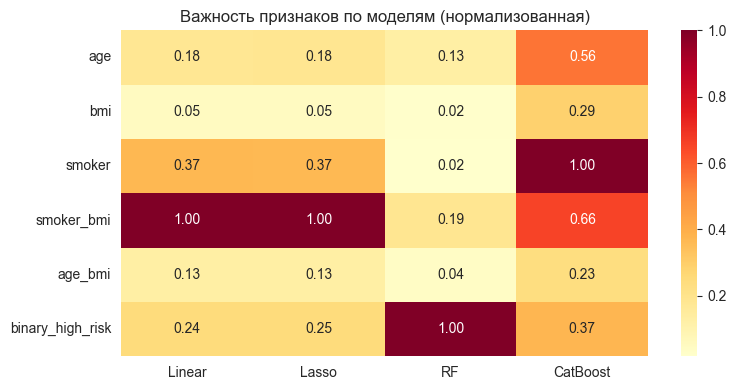

In [15]:
# ЗАДАНИЕ: получите важность признаков для каждой модели
#          визуализируйте, сравните и напишите вывод

linear_importance = np.abs(linear_model.coef_)
lasso_importance = np.abs(lasso_model.coef_)
rf_importance = rf_model.feature_importances_
catboost_importance = catboost_model.get_feature_importance()

importance_df = pd.DataFrame({
    'Linear': linear_importance,
    'Lasso': lasso_importance,
    'RF': rf_importance,
    'CatBoost': catboost_importance,
}, index=all_features)



# нормализуем для сравнения (у моделей разные шкалы)
importance_norm = importance_df / importance_df.max()
print(importance_norm)
# визуализация
plt.figure(figsize=(8, 4))
sns.heatmap(importance_norm, annot=True, fmt='.2f', cmap='YlOrRd')
plt.title('Важность признаков по моделям (нормализованная)')
plt.tight_layout()
plt.show()

**ВЫВОД**
- У линейной и лассо smoker_bmi = 1.0, smoker = 0.37 взаимодействие с bmi оказалось важнее самого факта курения
- У CatBoost smoker = 1.0, smoker_bmi = 0.66 — наоборот, сам факт курения важнее
- У RF: binary_high_risk = 1.0, всё остальное < 0.19

Думаю, это связано с тем, что между smoker, smoker_bmi и binary_high_risk высокая корреляция

Всем моделям оказались одинаково неважны bmi и age_bmi (только Catboost на них обратил внимание)

Теперь вы можете поэксперементировать с наборами признаков, чтобы получить лучшую метрику на тесте

In [16]:
# ЗАДАНИЕ: выберите одну модель, которой будете получать итоговое предсказание (R^2 метрика)
#          поэксперементируйте с наборами признаков и предъявите:
#              1. набор признаков и результаты обучения и теста с самым ПЛОХИМ скором
#              2. набор признаков и результаки обучения и теста с самым ХОРОШИМ скором


#Сначала сделаем плохо. Плохо сделать легко! 
worst_model_ever = CatBoostRegressor(
        iterations=500,
        depth=CATBOOST_DEPTH,
        learning_rate=CATBOOST_LEARNING_RATE,
        random_state=RANDOM_STATE,
        verbose=0
    )
data = df.copy()
worst_features = ['region','sex']
train, test = train_test_split(data, test_size=0.2, random_state=42)
y_train = train['charges'].copy()
y_test = test['charges'].copy()

worst_model_ever.fit(train[worst_features], y_train, cat_features=worst_features)
worst_score = worst_model_ever.score(test[worst_features], y_test)
print(f"worst CatBoostRegressor: {worst_score:.4f}")


# Узнал про pool в catboost, благодаря которому он сам может итеративно отбирать признаки. 
# Отдельным циклом решил поперебирать количество признаков, к которому надо прийти в итоге

from catboost import Pool
# После того, как Catboost отобрал 17 признаков, я решил накинуть ещё математических преобразований
df['log_age'] = np.log(df['age'])
df['log_bmi'] = np.log(df['bmi'])
df['sqrt_bmi'] = np.sqrt(df['bmi'])
df['bmi_children']   = df['bmi'] * df['children']
df['smoker_children'] = (df['smoker'] == 'yes').astype(int) * df['children']

data = df.copy()
train, test = train_test_split(data, test_size=0.2, random_state=42)
y_train = train['charges']
y_test  = test['charges']

all_features_pool = [
    'age', 'bmi', 'children', 'sex', 'smoker', 'region',
    'old', 'obese', 'binary_high_risk',
    'age_squared', 'bmi_squared', 'age_bmi', 'smoker_age',
    'smoker_bmi', 'numerical_risk', 'children_squared', 
    'age_children', 'log_age', 'log_bmi', 'sqrt_bmi',
    'bmi_children', 'smoker_children'
]
cat_features_pool = ['sex', 'smoker', 'region']

pool_train = Pool(train[all_features_pool], y_train, cat_features=cat_features_pool)
pool_test  = Pool(test[all_features_pool],  y_test,  cat_features=cat_features_pool)

#1) Экспериментально выяснено, что оптимальный k где-то в 10+ (при запуске на k in [3, 5, 7, 10, 13] получил лучший результат при k=13
#2) при k in [10, 11, 12, 13] снова получил 13. Видимо, стоит попробовать 13+ 
#3) при k in [13, 14, 15, 16, 17] получил 17. Поэтому добавил новых фишек и решил попробовать ещё
#4) всегда максимальный k выдаёт
for k in [17, 18, 19, 20, 21, 22]:
    selector = CatBoostRegressor(
        iterations=500,
        depth=CATBOOST_DEPTH,
        learning_rate=CATBOOST_LEARNING_RATE,
        random_state=RANDOM_STATE,
        verbose=0
    )
    result = selector.select_features(
        pool_train,
        eval_set=pool_test,
        features_for_select=all_features_pool,
        num_features_to_select=k,
        algorithm='RecursiveByShapValues',
        steps=5,
        verbose=0
    )
    selected = result['selected_features_names']
    selected_cat = [f for f in cat_features_pool if f in selected]
    pool_tr = Pool(train[selected], y_train, cat_features=selected_cat)
    pool_te = Pool(test[selected],  y_test,  cat_features=selected_cat)
    print(f"k={k:2d}  train={selector.score(pool_tr):.4f}  test={selector.score(pool_te):.4f}  признаки={selected}")

worst CatBoostRegressor: -0.0005
Step #1 out of 5

bestTest = 4265.216102
bestIteration = 129

Shrink model to first 130 iterations.
Feature #3 eliminated
Step #2 out of 5

bestTest = 4292.44574
bestIteration = 155

Shrink model to first 156 iterations.
Feature #5 eliminated
Step #3 out of 5

bestTest = 4242.311863
bestIteration = 102

Shrink model to first 103 iterations.
Feature #18 eliminated
Step #4 out of 5

bestTest = 4243.682866
bestIteration = 226

Shrink model to first 227 iterations.
Feature #19 eliminated
Step #5 out of 5

bestTest = 4248.777489
bestIteration = 173

Shrink model to first 174 iterations.
Feature #10 eliminated
Train final model

bestTest = 4283.223255
bestIteration = 96

Shrink model to first 97 iterations.
k=17  train=0.8755  test=0.8818  признаки=['age', 'bmi', 'children', 'smoker', 'old', 'obese', 'binary_high_risk', 'age_squared', 'age_bmi', 'smoker_age', 'smoker_bmi', 'numerical_risk', 'children_squared', 'age_children', 'log_age', 'bmi_children', 'smoke

The number of features selection steps (5) is greater than the number of features to eliminate (4). The number of steps was reduced to 4.



bestTest = 4265.216102
bestIteration = 129

Shrink model to first 130 iterations.
Feature #3 eliminated
Step #2 out of 4

bestTest = 4292.44574
bestIteration = 155

Shrink model to first 156 iterations.
Feature #5 eliminated
Step #3 out of 4

bestTest = 4242.311863
bestIteration = 102

Shrink model to first 103 iterations.
Feature #18 eliminated
Step #4 out of 4

bestTest = 4243.682866
bestIteration = 226

Shrink model to first 227 iterations.
Feature #19 eliminated
Train final model

bestTest = 4248.777489
bestIteration = 173

Shrink model to first 174 iterations.
k=18  train=0.8937  test=0.8837  признаки=['age', 'bmi', 'children', 'smoker', 'old', 'obese', 'binary_high_risk', 'age_squared', 'bmi_squared', 'age_bmi', 'smoker_age', 'smoker_bmi', 'numerical_risk', 'children_squared', 'age_children', 'log_age', 'bmi_children', 'smoker_children']
Step #1 out of 3


The number of features selection steps (5) is greater than the number of features to eliminate (3). The number of steps was reduced to 3.



bestTest = 4265.216102
bestIteration = 129

Shrink model to first 130 iterations.
Feature #3 eliminated
Step #2 out of 3

bestTest = 4292.44574
bestIteration = 155

Shrink model to first 156 iterations.
Feature #5 eliminated
Step #3 out of 3

bestTest = 4242.311863
bestIteration = 102

Shrink model to first 103 iterations.
Feature #18 eliminated
Train final model

bestTest = 4243.682866
bestIteration = 226

Shrink model to first 227 iterations.
k=19  train=0.9032  test=0.8840  признаки=['age', 'bmi', 'children', 'smoker', 'old', 'obese', 'binary_high_risk', 'age_squared', 'bmi_squared', 'age_bmi', 'smoker_age', 'smoker_bmi', 'numerical_risk', 'children_squared', 'age_children', 'log_age', 'sqrt_bmi', 'bmi_children', 'smoker_children']
Step #1 out of 2


...


bestTest = 4265.216102
bestIteration = 129

Shrink model to first 130 iterations.
Feature #3 eliminated
Step #2 out of 2

bestTest = 4292.44574
bestIteration = 155

Shrink model to first 156 iterations.
Feature #5 eliminated
Train final model

bestTest = 4242.311863
bestIteration = 102

Shrink model to first 103 iterations.
k=20  train=0.8766  test=0.8841  признаки=['age', 'bmi', 'children', 'smoker', 'old', 'obese', 'binary_high_risk', 'age_squared', 'bmi_squared', 'age_bmi', 'smoker_age', 'smoker_bmi', 'numerical_risk', 'children_squared', 'age_children', 'log_age', 'log_bmi', 'sqrt_bmi', 'bmi_children', 'smoker_children']
Step #1 out of 1


The number of features selection steps (5) is greater than the number of features to eliminate (1). The number of steps was reduced to 1.



bestTest = 4265.216102
bestIteration = 129

Shrink model to first 130 iterations.
Feature #3 eliminated
Train final model

bestTest = 4292.44574
bestIteration = 155

Shrink model to first 156 iterations.
k=21  train=0.8811  test=0.8813  признаки=['age', 'bmi', 'children', 'smoker', 'region', 'old', 'obese', 'binary_high_risk', 'age_squared', 'bmi_squared', 'age_bmi', 'smoker_age', 'smoker_bmi', 'numerical_risk', 'children_squared', 'age_children', 'log_age', 'log_bmi', 'sqrt_bmi', 'bmi_children', 'smoker_children']
Train final model


The number of features selection steps (5) is greater than the number of features to eliminate (0). The number of steps was reduced to 0.



bestTest = 4265.216102
bestIteration = 129

Shrink model to first 130 iterations.
k=22  train=0.8812  test=0.8828  признаки=['age', 'bmi', 'children', 'sex', 'smoker', 'region', 'old', 'obese', 'binary_high_risk', 'age_squared', 'bmi_squared', 'age_bmi', 'smoker_age', 'smoker_bmi', 'numerical_risk', 'children_squared', 'age_children', 'log_age', 'log_bmi', 'sqrt_bmi', 'bmi_children', 'smoker_children']


**ПАРА СЛОВ ОБ ИТОГАХ**

Больше придумывать фичи, чтобы получить метрику ещё лучше, не хочется. Прирост с каждым разом всё меньше, подозреваю, что потолок где-то около 0.8850 для таких гиперпараметров Catboost. 

Итог:
- Лучшая модель - ВСЕ фичи + новые:
    признаки=['age', 'bmi', 'children', 'smoker', 'old', 'obese', 'binary_high_risk', 'age_squared', 'age_bmi', 'smoker_age', 'smoker_bmi', 'numerical_risk', 'children_squared', 'age_children', 'log_age', 'bmi_children', 'smoker_children']
    $R^2$ на тесте: 0.8818
- Худшая модель - из признаков только `sex` и `region`:
    $R^2$ на тесте: -0.0005.
  
Я считаю прекрасные результаты, особенно с худшей моделью, хахаахах


Интересно посмотреть, какую важность имеют все 22 фичи, как мы это делали прежде. Хочу график

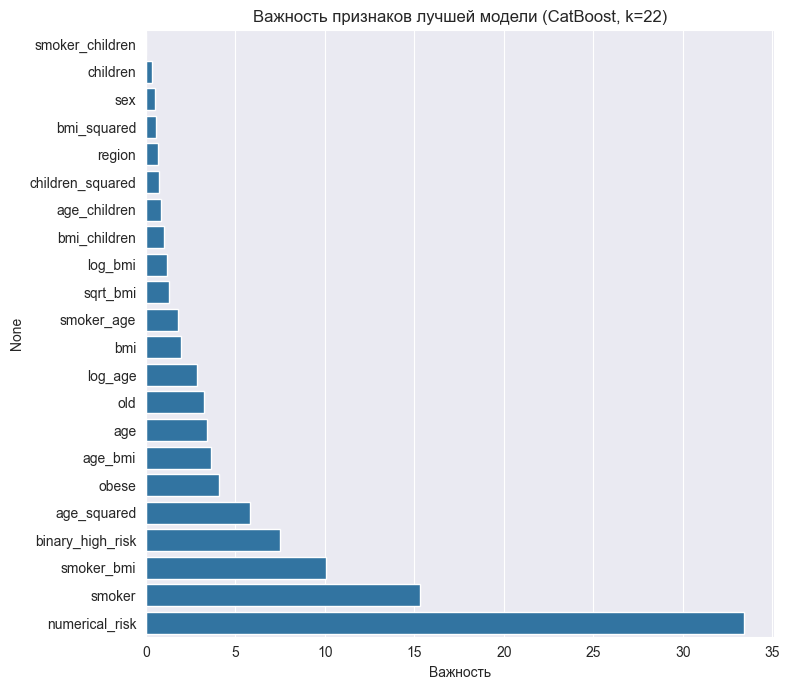

In [17]:
imp = pd.Series(selector.get_feature_importance(), index=selected).sort_values(ascending=True)
plt.figure(figsize=(8, 7))
sns.barplot(x=imp.values, y=imp.index, orient='h')
plt.xlabel('Важность')
plt.title('Важность признаков лучшей модели (CatBoost, k=22)')
plt.tight_layout()
plt.show()

# Практическое использование навыков (5 pt)

_В этот раз мы снова поработаем с вами с красивыми, но невкусными напитками._  

почему невкусными-то...

Возьмем датасет `Wine Quality` и задачу предсказания качества вина на основе физико-химических свойств. Целевой столбец — `quality`.

In [18]:
wine = pd.read_csv('WineQT.csv')
print(wine.shape)
wine.head()

(1143, 13)


,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,Id
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,0
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5,1
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5,2
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6,3
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,4


Нетрудно заметить, что это задача **многоклассовой классификации**.

***
**ЗАДАНИЕ**

Вам необходимо поработать с признаками и обучить случайный лес с фиксированными параметрами, которые нельзя менять.  
Необходимо достичь метрики **Accuracy** > 0.73 на тесте и **явно это показать** (это примерно на 5% больше, чем базово из коробки).

_**РАЗРЕШЕНО**_  

Эксперементировать с признаками и применять знания из превой части домашки

_**ЗАПРЕЩЕНО**_

Использовать другие модели и менять заданные константы, использовать другие параметры модели или какие-то неочевидные ивристики.

**ОЦЕНИВАЕТСЯ**
* Подготовка и обработка данных
* Анализ важности признаков
* Создание новых признаков и их отбор (в том числе их объяснение и интерпретация)
* Обучение и получение итоговой метрики
  
***

In [19]:
RANDOM_STATE = 42 # и для разбиения тоже
RF_N_ESTIMATORS = 150
RF_MAX_DEPTH = 10

model = RandomForestClassifier(
    n_estimators=RF_N_ESTIMATORS,
    max_depth=RF_MAX_DEPTH,
    random_state=RANDOM_STATE,
    n_jobs=-1
)

TEST_SIZE = 0.2 # для деления на train/test

In [20]:
wine = wine.drop(columns=['Id'])

In [21]:
print((wine.corr()['quality']).sort_values(ascending=False))
print(f'\n{wine['quality'].value_counts()}')
print(wine.duplicated().sum())
#wine = wine.drop_duplicates()
#wine = wine.dropna()

quality                 1.000000
alcohol                 0.484866
sulphates               0.257710
citric acid             0.240821
fixed acidity           0.121970
residual sugar          0.022002
pH                     -0.052453
free sulfur dioxide    -0.063260
chlorides              -0.124085
density                -0.175208
total sulfur dioxide   -0.183339
volatile acidity       -0.407394
Name: quality, dtype: float64

quality
5    483
6    462
7    143
4     33
8     16
3      6
Name: count, dtype: int64
125


In [22]:
# Очень тяжело придумывать фичи для вин, тут бы в химию и физику дела вникнуть. 
# По итогу просто перебирал различные преобразования, оставлял фичи, которые улучшают метрику. Это был тяжик.
wine['concentration'] = wine['alcohol'] / wine['density']
wine['sulphates_density'] = wine['sulphates'] / wine['density'] 
wine['sd_va'] = wine['sulphates_density'] * wine['volatile acidity']   
wine['fso2_sulphates'] = wine['free sulfur dioxide'] * wine['sulphates'] 

# убирать преобразованные фичи иногда повышает метрику (информация о их преобразовании может более удачно и полно описывать, чем они по отдельности)
X = wine.drop(columns=['quality', 'alcohol', 'density', 'free sulfur dioxide', 'sulphates'])
y = wine['quality']

In [23]:
# НЕ МЕНЯТЬ
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=TEST_SIZE, random_state=RANDOM_STATE, stratify=y
)

In [24]:
# SMOTE тут тоже не работает, всего 6 примеров 3 класса, добавляет лишь шум

# from imblearn.over_sampling import SMOTE
# sm = SMOTE(random_state=RANDOM_STATE, k_neighbors=2)
# X_train_res, y_train_res = sm.fit_resample(X_train, y_train)
# model.fit(X_train_res, y_train_res)
model.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",150
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",10
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric(y

In [25]:
feat_imp = pd.Series(model.feature_importances_, index=X.columns).sort_values(ascending=False)
print(feat_imp)

concentration           0.186301
sulphates_density       0.128622
volatile acidity        0.099005
total sulfur dioxide    0.091114
sd_va                   0.077771
fso2_sulphates          0.073497
fixed acidity           0.072248
chlorides               0.071600
citric acid             0.069880
pH                      0.069816
residual sugar          0.060146
dtype: float64


In [26]:
from sklearn.inspection import permutation_importance

perm = permutation_importance(model, X_test, y_test, n_repeats=10, random_state=RANDOM_STATE, n_jobs=-1)
perm_imp = pd.Series(perm.importances_mean, index=X.columns).sort_values(ascending=False)

comparison = pd.DataFrame({
    "MDI": feat_imp,
    "Permutation": perm_imp
}).sort_values("Permutation", ascending=False)
print(comparison)

# Признаки важные по обоим методам можно оставить
# Важные по MDI, но не по Permutation - лучше убрать

                           MDI  Permutation
concentration         0.186301     0.168996
sulphates_density     0.128622     0.104803
volatile acidity      0.099005     0.059389
total sulfur dioxide  0.091114     0.049782
citric acid           0.069880     0.043668
fso2_sulphates        0.073497     0.041485
chlorides             0.071600     0.034061
fixed acidity         0.072248     0.034061
sd_va                 0.077771     0.031004
residual sugar        0.060146     0.026201
pH                    0.069816     0.024454


In [27]:
y_pred = model.predict(X_test)
score = accuracy_score(y_test, y_pred)
assert score > 0.7
print(f"Accuracy (Multi-class): {score:.4f}")

Accuracy (Multi-class): 0.7249


**ОТЧЕТ О ПРОДЕЛАННОЙ РАБОТЕ** достаточно описания ваших попыток и того, к чему в итоге пришли

#### Главный вывод

Главное, что я для себя усвоил: для деревьев неплохой практикой является заменение двух признаков на их преобразование. Это хорошо сработало на некоторых признаках - добавить их произведение / отношение, удалить исходные. Долго пробовал ещё заменять / добавлять / удалять, метрики лучше не достиг.


#### Логи экспериментов

До изменения модели
1) 0.5764192139737991
2) 0.5895196506550219 (минус ['quality', 'pH', 'residual sugar', 'free sulfur dioxide'])
3) 0.4803921568627451 (сделал dropna и dropduplicates. очень странно, что это сильно ухудшает метрику.)
4) 0.5938864628820961 (добавил концентрацию). Кажется, я упускаю что-то очень важное.
5) 0.5720524017467249 (добавил больше признаков).
6) 0.7816593886462883 (решил считерить, заменил классы 3-4 на 1, 5-6 на 2, 7-8 на 3. Хочу всё же сделать норм, без читерства)
7) 0.5982532751091703 (добавил фичи, поудалял мультиколлинеарность)

Поменялась модель
1) 0.6986
2) 0.7118 - Добавил концентрацию алкоголя и сульфатов, убрал остальные фичи. 
3) 0.7162 - Добавил взаимодействие сульфатов и кислотности (чем выше это соотношение, тем лучше вино)

**Итог: 0.7249 - Добавил взаимодействие сульфатов и свободного so2**


Фичи, от использования которых отказался (Перечисленные признаки либо не давали прироста, либо ухудшали метрику):
```
wine['so2'] = wine['free sulfur dioxide'] / wine['total sulfur dioxide']
wine['acid_ratio'] = wine['volatile acidity'] / wine['fixed acidity']
wine['sulphates_alcohol'] = wine['sulphates'] * wine['alcohol']
wine['log_chlorides'] = np.log1p(wine['chlorides']) 
wine['log_volatile_acidity'] = np.log1p(wine['volatile acidity'])
wine['log_sulphates'] = np.log1p(wine['sulphates'])
wine['alcohol_sq'] = wine['alcohol'] ** 2
wine['sulphates_sq'] = wine['sulphates'] ** 2
wine['alc_sulph_citric'] = wine['alcohol'] * wine['sulphates'] * wine['citric acid']
```